## Importing and Setup

In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_ESTIMATORS = 200
MAX_DEPTH = 6


## Loading Data

In [3]:
bunch = load_breast_cancer(as_frame=True)
raw_df = bunch.frame  ##30 feature columns + 'target'

print("Raw data shape:", raw_df.shape)
print("Target classes:", dict(zip(bunch.target_names, range(len(bunch.target_names)))))
raw_df.head()

Raw data shape: (569, 31)
Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Data Processing

In [4]:
processed_df = raw_df.copy()
processed_df.columns = [c.strip().replace(" ", "_") for c in processed_df.columns]

before = processed_df.shape[0]
processed_df = processed_df.drop_duplicates()
print(f"Dropped {before - processed_df.shape[0]} duplicate rows")

missing = processed_df.isnull().sum().sum()
print(f"Missing values: {missing}")
if missing > 0:
    processed_df = processed_df.fillna(processed_df.median(numeric_only=True))

processed_df["target"] = processed_df["target"].astype(int)
processed_df.describe().T.head()

Dropped 0 duplicate rows
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean_texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean_perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean_area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean_smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


## Feature Eng

In [5]:
X = processed_df.drop(columns=["target"])
y = processed_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)
X_train_scaled.head()

Train shape: (455, 30)
Test shape : (114, 30)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


## Model Training

In [6]:
model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
)
model.fit(X_train_scaled, y_train)
print("Model trained:", model)

Model trained: RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)


## Model Eval

In [7]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

print(json.dumps(metrics, indent=4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=bunch.target_names))

{
    "accuracy": 0.9473684210526315,
    "precision": 0.9583333333333334,
    "recall": 0.9583333333333334,
    "f1_score": 0.9583333333333334,
    "roc_auc": 0.994047619047619
}

Classification report:

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



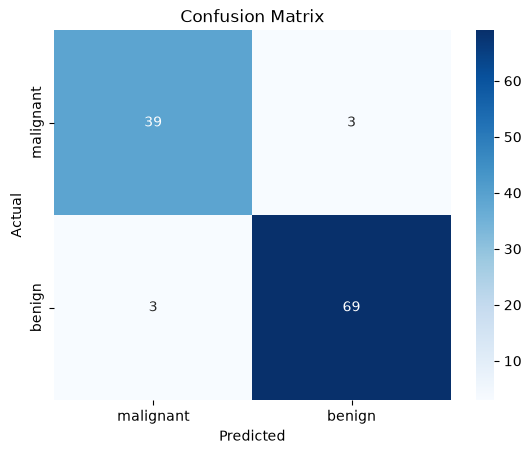

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=bunch.target_names, yticklabels=bunch.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## How DVC?

| Stage | Notebook section | Equivalent script |
|---|---|---|
| 1. Data Ingestion | Step 1 | `src/data_ingestion.py` |
| 2. Data Preprocessing | Step 2 | `src/data_preprocessing.py` |
| 3. Feature Engineering | Step 3 | `src/feature_engineering.py` |
| 4. Model Building | Step 4 | `src/model_building.py` |
| 5. Model Evaluation | Step 5 | `src/model_evaluation.py` |